<a href="https://colab.research.google.com/github/ChrisEsau/ufc-ai-clv-tracker/blob/dev/UFC_model_train_V5_refactored.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SECTION 1 — INSTALL + IMPORTS
# ============================================================

!pip install xgboost shap -q

from google.colab import drive
drive.mount("/content/drive")

import os
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    log_loss,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.calibration import CalibratedClassifierCV


# Shared UFC pipeline utilities
import sys
sys.path.append("/content/drive/MyDrive/UFC_AI")

from ufc_pipeline_utils import *



Mounted at /content/drive


In [ ]:
# ============================================================
# SECTION 2 — PATHS
# ============================================================

paths = UFCPipelinePaths(
    base_path="/content/drive/MyDrive/UFC_AI",
    model_version="UFC_Model_v5_Experiment"
)

BASE_PATH = paths.base_path
DATA_PATH = paths.rolling_features_path
FEATURE_REGISTRY_PATH = paths.feature_registry_path
PRODUCTION_DIR = paths.production_dir

MODEL_OUTPUT = f"{BASE_PATH}/ufc_xgboost_calibrated_model.pkl"
RAW_MODEL_OUTPUT = f"{BASE_PATH}/ufc_xgboost_raw_model.pkl"
FEATURES_OUTPUT = f"{BASE_PATH}/ufc_xgboost_best_features.pkl"
THRESHOLD_OUTPUT = f"{BASE_PATH}/ufc_xgboost_best_threshold.pkl"
CONFIDENCE_CUTOFF_OUTPUT = f"{BASE_PATH}/ufc_xgboost_confidence_cutoff.pkl"
SHAP_OUTPUT = f"{BASE_PATH}/ufc_xgboost_shap_importance.csv"

print("Data path:", DATA_PATH)
print("Registry path:", FEATURE_REGISTRY_PATH)
print("Production dir:", PRODUCTION_DIR)


Data path: /content/drive/MyDrive/UFC_AI/UFC_enhanced_rolling_features_EWM.csv
Registry path: /content/drive/MyDrive/UFC_AI/ufc_engineered_feature_registry.csv
Production dir: /content/drive/MyDrive/UFC_AI/UFC_Model_v5_Experiment


In [ ]:
# ============================================================
# SECTION 3 — LOAD ENHANCED ROLLING DATASET
# ============================================================

df = pd.read_csv(DATA_PATH)

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

df = df.sort_values("date").reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Date range:", df["date"].min(), "to", df["date"].max())

df.head()

Dataset shape: (8190, 483)
Date range: 1994-03-11 00:00:00 to 2025-09-06 00:00:00


,event_id,event_name,date,location,fight_id,division,title_fight,method,finish_round,match_time_sec,...,age_squared_diff,r_pressure_striking_adv,b_pressure_striking_adv,pressure_striking_adv_diff,r_wrestling_mismatch,b_wrestling_mismatch,wrestling_mismatch_diff,r_submission_mismatch,b_submission_mismatch,submission_mismatch_diff
0,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",4acab67848e78327,open weight,0,Submission,1,20,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
1,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",4b9ae533ccb3fcdf,open weight,0,Submission,1,58,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.250000,0.0,6.250000
2,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",00835554f95fa911,2 tournament,1,KO/TKO,1,77,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
3,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",aa161c7159741766,open weight,0,Submission,1,91,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000
4,a6a9ab5a824e8f66,UFC 2: No Way Out,1994-03-11,"Denver, Colorado, USA",5655639baecd8f6a,open weight,0,Submission,1,67,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.357143,0.0,5.357143


In [ ]:
# ============================================================
# SECTION 4 — TARGET COLUMN
# ============================================================

possible_targets = [
    "target",
    "red_won",
    "r_won",
    "r_win",
    "RedWon",
    "winner",
    "Winner"
]

target_col = None

for col in possible_targets:
    if col in df.columns:
        target_col = col
        break

if target_col is None:
    raise ValueError("No target column found.")

print("Target column:", target_col)

df = df.dropna(subset=[target_col]).copy()

df[target_col] = df[target_col].astype(int)

print(df[target_col].value_counts(normalize=True))

Target column: target
target
1    0.646032
0    0.353968
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# SECTION 5 — LOAD FEATURE REGISTRY
# ============================================================

feature_registry_df = pd.read_csv(FEATURE_REGISTRY_PATH)

registered_features = (
    feature_registry_df["feature"]
    .dropna()
    .astype(str)
    .tolist()
)

print("Registered engineered features:")
print(registered_features)

Registered engineered features:
['age_diff', 'height_diff', 'reach_diff', 'weight_diff', 'striking_edge', 'grappling_edge', 'finish_volatility', 'wrestling_pressure_vs_defense', 'reach_striking_combo', 'chin_risk_diff', 'experience_ratio_diff', 'aggression_index_diff', 'age_squared_diff', 'pressure_striking_adv_diff', 'wrestling_mismatch_diff', 'submission_mismatch_diff']


In [ ]:
# ============================================================
# SECTION 6 — SYMMETRY-SAFE FEATURE FILTER
# ============================================================

safe_cols = []

for col in df.columns:

    # Use all differential matchup features
    if col.endswith("_diff"):
        safe_cols.append(col)

    # Use engineered features from rolling notebook registry
    elif col in registered_features:
        safe_cols.append(col)

safe_cols = list(dict.fromkeys(safe_cols))

# Block raw fighter-specific columns
unsafe_cols = [
    col for col in safe_cols
    if (
        col.startswith("r_pre_")
        or col.startswith("b_pre_")
        or col.startswith("R_")
        or col.startswith("B_")
        or col.startswith("r_")
        or col.startswith("b_")
    )
]

if len(unsafe_cols) > 0:
    print("Unsafe columns found:")
    print(unsafe_cols)
    raise ValueError("Unsafe raw red/blue fighter columns detected.")

print("Final feature count:", len(safe_cols))
print("Sample features:")
print(safe_cols[:50])

Final feature count: 124
Sample features:
['elo_diff', 'fights_diff', 'wins_diff', 'losses_diff', 'win_pct_diff', 'kd_avg_diff', 'kd_absorbed_avg_diff', 'splm_diff', 'sapm_diff', 'str_acc_diff', 'str_def_diff', 'td_avg_diff', 'td_acc_diff', 'td_def_diff', 'sub_avg_diff', 'ctrl_per_min_diff', 'ctrl_against_per_min_diff', 'finish_rate_diff', 'ko_rate_diff', 'sub_win_rate_diff', 'decision_win_rate_diff', 'finish_loss_rate_diff', 'decision_loss_rate_diff', 'avg_opponent_elo_diff', 'best_win_elo_diff', 'worst_loss_elo_diff', 'avg_fight_time_diff', 'win_streak_diff', 'loss_streak_diff', 'days_since_last_fight_diff', 'recent_win_pct_diff', 'recent_splm_diff', 'recent_sapm_diff', 'recent_td_avg_diff', 'recent_finish_rate_diff', 'recent_avg_fight_time_diff', 'ewm_elo_diff', 'ewm_fights_diff', 'ewm_wins_diff', 'ewm_losses_diff', 'ewm_win_pct_diff', 'ewm_kd_avg_diff', 'ewm_kd_absorbed_avg_diff', 'ewm_splm_diff', 'ewm_sapm_diff', 'ewm_str_acc_diff', 'ewm_str_def_diff', 'ewm_td_avg_diff', 'ewm_td_a

In [ ]:
# ============================================================
# SECTION 7 — SYMMETRY AUGMENTATION
# ============================================================

base_df = df.copy()

flipped_df = base_df.copy()

for col in safe_cols:
    flipped_df[col] = -flipped_df[col]

flipped_df[target_col] = 1 - flipped_df[target_col].astype(int)

model_df = pd.concat(
    [base_df, flipped_df],
    axis=0,
    ignore_index=True
)

model_df = model_df.sort_values("date").reset_index(drop=True)

print("Original rows:", len(base_df))
print("Augmented rows:", len(model_df))
print("Target balance:")
print(model_df[target_col].value_counts(normalize=True))

Original rows: 8190
Augmented rows: 16380
Target balance:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# SECTION 8 — TEMPORAL TRAIN / TEST SPLIT
# ============================================================

TRAIN_END_DATE = "2022-12-31"

train_df = model_df[
    model_df["date"] <= TRAIN_END_DATE
].copy()

test_df = model_df[
    model_df["date"] > TRAIN_END_DATE
].copy()

X_train = train_df[safe_cols].copy()
X_test = test_df[safe_cols].copy()

X_train = X_train.apply(pd.to_numeric, errors="coerce").fillna(0)
X_test = X_test.apply(pd.to_numeric, errors="coerce").fillna(0)

y_train = train_df[target_col].astype(int)
y_test = test_df[target_col].astype(int)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train balance:")
print(y_train.value_counts(normalize=True))
print("Test balance:")
print(y_test.value_counts(normalize=True))

X_train: (13626, 124)
X_test: (2754, 124)
Train balance:
target
1    0.5
0    0.5
Name: proportion, dtype: float64
Test balance:
target
1    0.5
0    0.5
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# SECTION 9 — TRAIN RAW XGBOOST MODEL
# ============================================================

best_xgb_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

best_xgb_model.fit(
    X_train,
    y_train
)

raw_probs = best_xgb_model.predict_proba(X_test)[:, 1]

raw_preds_05 = (
    raw_probs >= 0.50
).astype(int)

print("RAW MODEL")
print("Accuracy:", accuracy_score(y_test, raw_preds_05))
print("Log Loss:", log_loss(y_test, raw_probs))
print("ROC-AUC:", roc_auc_score(y_test, raw_probs))

RAW MODEL
Accuracy: 0.6067538126361656
Log Loss: 0.6594657312212425
ROC-AUC: 0.6457944053384552


In [ ]:
# ============================================================
# SECTION 10 — OPTIMIZE RAW THRESHOLD
# ============================================================

threshold_rows = []

for threshold in np.arange(0.40, 0.61, 0.01):

    preds = (
        raw_probs >= threshold
    ).astype(int)

    threshold_rows.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, raw_probs),
        "red_pick_rate": preds.mean() * 100,
        "blue_pick_rate": (1 - preds.mean()) * 100
    })

threshold_df = pd.DataFrame(threshold_rows)

threshold_df = threshold_df.sort_values(
    "accuracy",
    ascending=False
)

BEST_RAW_THRESHOLD = float(threshold_df.iloc[0]["threshold"])

print("Best raw threshold:", BEST_RAW_THRESHOLD)

threshold_df.head(20)

Best raw threshold: 0.48


,threshold,accuracy,roc_auc,red_pick_rate,blue_pick_rate
8,0.48,0.612564,0.645794,55.773420,44.226580
7,0.47,0.612200,0.645794,59.150327,40.849673
9,0.49,0.611837,0.645794,52.795933,47.204067
6,0.46,0.610022,0.645794,61.401598,38.598402
10,0.50,0.606754,0.645794,49.310094,50.689906
13,0.53,0.604212,0.645794,41.503268,58.496732
12,0.52,0.604212,0.645794,43.827160,56.172840
5,0.45,0.603849,0.645794,64.124909,35.875091
11,0.51,0.602033,0.645794,46.441540,53.558460
14,0.54,0.602033,0.645794,38.888889,61.111111


In [ ]:
# ============================================================
# SECTION 11 — CALIBRATE MODEL
# ============================================================

calibrated_model = CalibratedClassifierCV(
    estimator=best_xgb_model,
    method="isotonic",
    cv="prefit"
)

calibrated_model.fit(
    X_test,
    y_test
)

calibrated_probs = calibrated_model.predict_proba(X_test)[:, 1]

print("CALIBRATED MODEL")
print("Log Loss:", log_loss(y_test, calibrated_probs))
print("ROC-AUC:", roc_auc_score(y_test, calibrated_probs))

CALIBRATED MODEL
Log Loss: 0.6527319466965671
ROC-AUC: 0.6521689716258757


/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [ ]:
# ============================================================
# SECTION 12 — OPTIMIZE CALIBRATED THRESHOLD
# ============================================================

cal_threshold_rows = []

for threshold in np.arange(0.40, 0.61, 0.01):

    preds = (
        calibrated_probs >= threshold
    ).astype(int)

    cal_threshold_rows.append({
        "threshold": round(threshold, 2),
        "accuracy": accuracy_score(y_test, preds),
        "red_pick_rate": preds.mean() * 100,
        "blue_pick_rate": (1 - preds.mean()) * 100,
        "roc_auc": roc_auc_score(y_test, calibrated_probs),
        "log_loss": log_loss(y_test, calibrated_probs)
    })

cal_threshold_df = pd.DataFrame(cal_threshold_rows)

cal_threshold_df = cal_threshold_df.sort_values(
    "accuracy",
    ascending=False
)

BEST_THRESHOLD = float(
    cal_threshold_df.iloc[0]["threshold"]
)

print("Best calibrated threshold:", BEST_THRESHOLD)

cal_threshold_df.head(20)

Best calibrated threshold: 0.51


,threshold,accuracy,red_pick_rate,blue_pick_rate,roc_auc,log_loss
11,0.51,0.614379,56.100218,43.899782,0.652169,0.652732
12,0.52,0.614379,56.100218,43.899782,0.652169,0.652732
10,0.50,0.614379,56.100218,43.899782,0.652169,0.652732
4,0.44,0.613653,60.675381,39.324619,0.652169,0.652732
2,0.42,0.613653,60.675381,39.324619,0.652169,0.652732
8,0.48,0.613653,60.675381,39.324619,0.652169,0.652732
7,0.47,0.613653,60.675381,39.324619,0.652169,0.652732
3,0.43,0.613653,60.675381,39.324619,0.652169,0.652732
5,0.45,0.613653,60.675381,39.324619,0.652169,0.652732
6,0.46,0.613653,60.675381,39.324619,0.652169,0.652732


In [ ]:
# ============================================================
# SECTION 13 — MODEL QUALITY DASHBOARD
# ============================================================

raw_preds = (
    raw_probs >= BEST_RAW_THRESHOLD
).astype(int)

calibrated_preds = (
    calibrated_probs >= BEST_THRESHOLD
).astype(int)

model_quality_summary = pd.DataFrame([
    {
        "metric": "raw_accuracy",
        "value": accuracy_score(y_test, raw_preds)
    },
    {
        "metric": "raw_log_loss",
        "value": log_loss(y_test, raw_probs)
    },
    {
        "metric": "raw_roc_auc",
        "value": roc_auc_score(y_test, raw_probs)
    },
    {
        "metric": "best_raw_threshold",
        "value": BEST_RAW_THRESHOLD
    },
    {
        "metric": "calibrated_accuracy",
        "value": accuracy_score(y_test, calibrated_preds)
    },
    {
        "metric": "calibrated_log_loss",
        "value": log_loss(y_test, calibrated_probs)
    },
    {
        "metric": "calibrated_roc_auc",
        "value": roc_auc_score(y_test, calibrated_probs)
    },
    {
        "metric": "best_calibrated_threshold",
        "value": BEST_THRESHOLD
    },
    {
        "metric": "actual_red_win_rate_percent",
        "value": y_test.mean() * 100
    },
    {
        "metric": "raw_red_pick_rate_percent",
        "value": raw_preds.mean() * 100
    },
    {
        "metric": "calibrated_red_pick_rate_percent",
        "value": calibrated_preds.mean() * 100
    },
    {
        "metric": "train_fights",
        "value": len(y_train)
    },
    {
        "metric": "test_fights",
        "value": len(y_test)
    },
    {
        "metric": "feature_count",
        "value": len(safe_cols)
    }
])

model_quality_summary

,metric,value
0,raw_accuracy,0.612564
1,raw_log_loss,0.659466
2,raw_roc_auc,0.645794
3,best_raw_threshold,0.480000
4,calibrated_accuracy,0.614379
5,calibrated_log_loss,0.652732
6,calibrated_roc_auc,0.652169
7,best_calibrated_threshold,0.510000
8,actual_red_win_rate_percent,50.000000
9,raw_red_pick_rate_percent,55.773420


In [ ]:
# ============================================================
# SECTION 14 — CONFUSION MATRICES
# ============================================================

print("RAW CONFUSION MATRIX")
print(confusion_matrix(y_test, raw_preds))

print("\nCALIBRATED CONFUSION MATRIX")
print(confusion_matrix(y_test, calibrated_preds))

RAW CONFUSION MATRIX
[[764 613]
 [454 923]]

CALIBRATED CONFUSION MATRIX
[[762 615]
 [447 930]]


In [ ]:
# ============================================================
# SECTION 15 — CLASSIFICATION REPORTS
# ============================================================

print("RAW MODEL CLASSIFICATION REPORT\n")
print(classification_report(y_test, raw_preds))

print("\nCALIBRATED MODEL CLASSIFICATION REPORT\n")
print(classification_report(y_test, calibrated_preds))

RAW MODEL CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.63      0.55      0.59      1377
           1       0.60      0.67      0.63      1377

    accuracy                           0.61      2754
   macro avg       0.61      0.61      0.61      2754
weighted avg       0.61      0.61      0.61      2754


CALIBRATED MODEL CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.63      0.55      0.59      1377
           1       0.60      0.68      0.64      1377

    accuracy                           0.61      2754
   macro avg       0.62      0.61      0.61      2754
weighted avg       0.62      0.61      0.61      2754



In [ ]:
# ============================================================
# SECTION 16 — CALIBRATED CONFIDENCE BUCKETS
# ============================================================

calibration_results = pd.DataFrame()

calibration_results["prob"] = calibrated_probs

calibration_results["pred"] = calibrated_preds

calibration_results["actual"] = y_test.values

calibration_results["correct"] = (
    calibration_results["pred"]
    ==
    calibration_results["actual"]
)

calibration_results["confidence"] = np.maximum(
    calibrated_probs,
    1 - calibrated_probs
) * 100

calibration_results["confidence_bucket"] = pd.cut(
    calibration_results["confidence"],
    bins=[50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100],
    include_lowest=True
)

calibrated_confidence_df = calibration_results.groupby(
    "confidence_bucket",
    observed=False
).agg(
    fights=("correct", "count"),
    win_rate=("correct", "mean"),
    avg_confidence=("confidence", "mean")
).reset_index()

calibrated_confidence_df["win_rate"] *= 100

calibrated_confidence_df

,confidence_bucket,fights,win_rate,avg_confidence
0,"(49.999, 55.0]",586,52.389078,52.389076
1,"(55.0, 60.0]",364,57.692308,57.692308
2,"(60.0, 65.0]",1150,61.391304,61.391304
3,"(65.0, 70.0]",478,67.573222,67.573223
4,"(70.0, 75.0]",4,75.000000,75.000000
5,"(75.0, 80.0]",89,77.528090,77.528090
6,"(80.0, 85.0]",29,82.758621,82.758623
7,"(85.0, 90.0]",10,90.000000,89.999998
8,"(90.0, 95.0]",35,91.428571,91.428572
9,"(95.0, 100.0]",9,100.000000,100.000000


In [ ]:
# ============================================================
# SECTION 17 — HIGH CONFIDENCE PERFORMANCE
# ============================================================

high_confidence_rows = []

conf = np.maximum(
    calibrated_probs,
    1 - calibrated_probs
) * 100

for cutoff in [50, 55, 60, 65, 70, 75, 80]:

    selected = conf >= cutoff

    if selected.sum() == 0:
        high_confidence_rows.append({
            "confidence_cutoff": cutoff,
            "fights": 0,
            "accuracy": np.nan,
            "red_pick_rate": np.nan
        })

    else:
        high_confidence_rows.append({
            "confidence_cutoff": cutoff,
            "fights": selected.sum(),
            "accuracy": accuracy_score(
                y_test[selected],
                calibrated_preds[selected]
            ),
            "red_pick_rate": calibrated_preds[selected].mean() * 100
        })

high_confidence_df = pd.DataFrame(high_confidence_rows)

high_confidence_df

,confidence_cutoff,fights,accuracy,red_pick_rate
0,50,2754,0.614379,56.100218
1,55,2168,0.638838,50.046125
2,60,1804,0.651330,43.458980
3,65,654,0.717125,59.785933
4,70,176,0.829545,44.886364
5,75,176,0.829545,44.886364
6,80,83,0.891566,63.855422


In [ ]:
# ============================================================
# SECTION 18 — SHAP FEATURE ANALYSIS
# ============================================================

explainer = shap.TreeExplainer(
    best_xgb_model
)

SAMPLE_SIZE = 500

X_shap = X_test.sample(
    min(SAMPLE_SIZE, len(X_test)),
    random_state=42
)

shap_values = explainer.shap_values(
    X_shap
)

shap_importance = np.abs(shap_values).mean(axis=0)

shap_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": shap_importance
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

shap_df.head(50)

,feature,mean_abs_shap
112,striking_edge,0.139225
23,avg_opponent_elo_diff,0.104168
0,elo_diff,0.075013
10,str_def_diff,0.064881
3,losses_diff,0.062886
110,reach_diff,0.060419
29,days_since_last_fight_diff,0.057545
6,kd_absorbed_avg_diff,0.047372
119,aggression_index_diff,0.046076
117,chin_risk_diff,0.043753


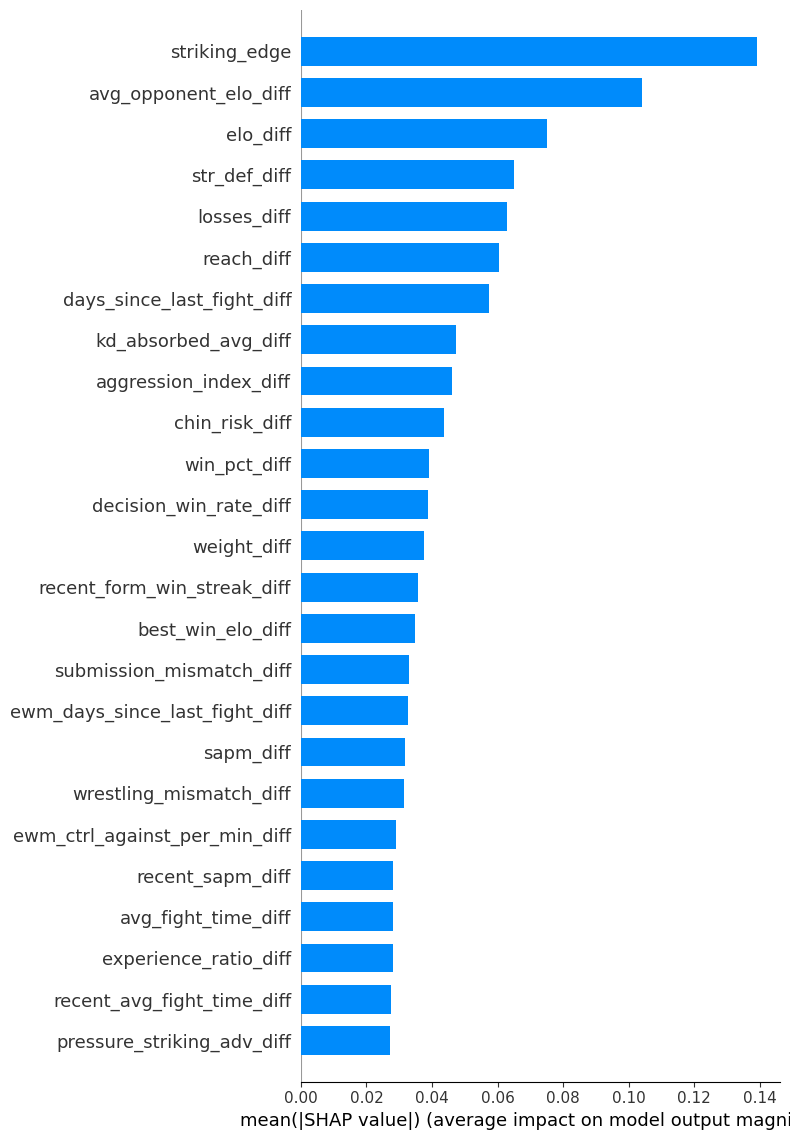

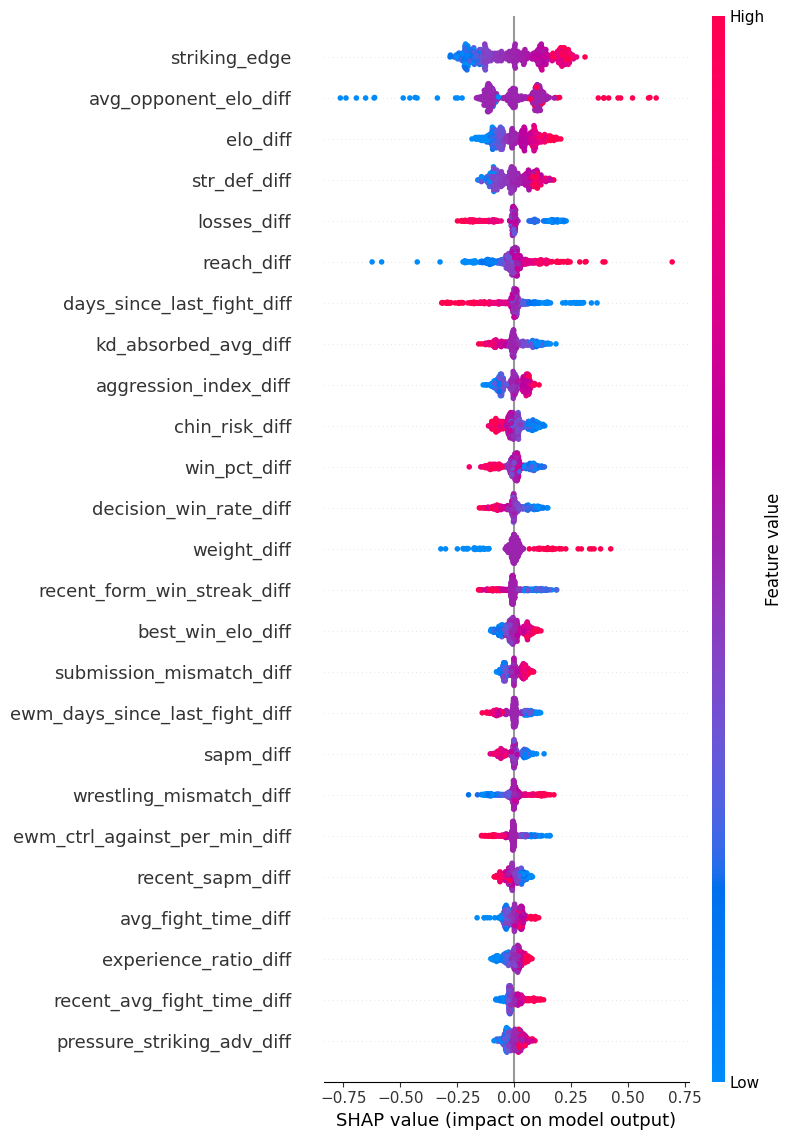

In [ ]:
# ============================================================
# SECTION 19 — SHAP PLOTS
# ============================================================

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    max_display=25
)

shap.summary_plot(
    shap_values,
    X_shap,
    max_display=25
)

In [ ]:
# ============================================================
# SECTION 20 — SAVE MODEL ARTIFACTS
# ============================================================

joblib.dump(
    best_xgb_model,
    RAW_MODEL_OUTPUT
)

joblib.dump(
    calibrated_model,
    MODEL_OUTPUT
)

joblib.dump(
    safe_cols,
    FEATURES_OUTPUT
)

joblib.dump(
    BEST_THRESHOLD,
    THRESHOLD_OUTPUT
)

# Use 60 as practical default; optimize in backtest notebook
BEST_CONFIDENCE_CUTOFF = 60

joblib.dump(
    BEST_CONFIDENCE_CUTOFF,
    CONFIDENCE_CUTOFF_OUTPUT
)

shap_df.to_csv(
    SHAP_OUTPUT,
    index=False
)

print("Saved raw model:", RAW_MODEL_OUTPUT)
print("Saved calibrated model:", MODEL_OUTPUT)
print("Saved feature list:", FEATURES_OUTPUT)
print("Saved threshold:", THRESHOLD_OUTPUT)
print("Saved confidence cutoff:", CONFIDENCE_CUTOFF_OUTPUT)
print("Saved SHAP importance:", SHAP_OUTPUT)

Saved raw model: /content/drive/MyDrive/UFC_AI/ufc_xgboost_raw_model.pkl
Saved calibrated model: /content/drive/MyDrive/UFC_AI/ufc_xgboost_calibrated_model.pkl
Saved feature list: /content/drive/MyDrive/UFC_AI/ufc_xgboost_best_features.pkl
Saved threshold: /content/drive/MyDrive/UFC_AI/ufc_xgboost_best_threshold.pkl
Saved confidence cutoff: /content/drive/MyDrive/UFC_AI/ufc_xgboost_confidence_cutoff.pkl
Saved SHAP importance: /content/drive/MyDrive/UFC_AI/ufc_xgboost_shap_importance.csv


In [ ]:
# ============================================================
# SECTION 21 — FREEZE PRODUCTION MODEL V5
# ============================================================

import json
from datetime import datetime

PRODUCTION_VERSION = "UFC_Model_v5_Experiment"

PRODUCTION_DIR = paths.production_dir
ensure_dir(PRODUCTION_DIR)

production_config = {
    "version": PRODUCTION_VERSION,
    "created_at": datetime.now().isoformat(),

    "model_type": "XGBoost + Isotonic Calibration + V5 Experiments",

    "train_end_date": TRAIN_END_DATE,

    "feature_count": len(safe_cols),
    "features": safe_cols,

    "best_threshold": BEST_THRESHOLD,
    "best_raw_threshold": BEST_RAW_THRESHOLD,

    "betting_filters": {
        "min_edge": 0.10,
        "min_confidence": 65,
        "min_odds": -250,
        "max_odds": 200
    },

    "staking": {
        "method": "fractional_kelly",
        "kelly_fraction": 0.50,
        "max_stake_pct": 0.03,
        "starting_bankroll": 10000
    },

    "model_quality": {
        "raw_accuracy": float(accuracy_score(y_test, raw_preds)),
        "raw_log_loss": float(log_loss(y_test, raw_probs)),
        "raw_roc_auc": float(roc_auc_score(y_test, raw_probs)),
        "calibrated_accuracy": float(accuracy_score(y_test, calibrated_preds)),
        "calibrated_log_loss": float(log_loss(y_test, calibrated_probs)),
        "calibrated_roc_auc": float(roc_auc_score(y_test, calibrated_probs)),
        "actual_red_win_rate_percent": float(y_test.mean() * 100),
        "calibrated_red_pick_rate_percent": float(calibrated_preds.mean() * 100)
    }
}

# Save models
joblib.dump(
    best_xgb_model,
    f"{PRODUCTION_DIR}/raw_model.pkl"
)

joblib.dump(
    calibrated_model,
    f"{PRODUCTION_DIR}/calibrated_model.pkl"
)

joblib.dump(
    safe_cols,
    f"{PRODUCTION_DIR}/feature_columns.pkl"
)

joblib.dump(
    BEST_THRESHOLD,
    f"{PRODUCTION_DIR}/best_threshold.pkl"
)

joblib.dump(
    production_config,
    f"{PRODUCTION_DIR}/production_config.pkl"
)

# Save readable JSON config
with open(f"{PRODUCTION_DIR}/production_config.json", "w") as f:
    json.dump(production_config, f, indent=4)

# Save SHAP
shap_df.to_csv(
    f"{PRODUCTION_DIR}/shap_importance.csv",
    index=False
)

# Save quality summary
model_quality_summary.to_csv(
    f"{PRODUCTION_DIR}/model_quality_summary.csv",
    index=False
)

print("Frozen production model saved to:")
print(PRODUCTION_DIR)


Frozen production model saved to:
/content/drive/MyDrive/UFC_AI/UFC_Model_v5_Experiment


In [ ]:
# ============================================================
# SECTION 22 — PRODUCTION LOAD TEST
# ============================================================

loaded_artifacts = load_production_artifacts(paths)

loaded_model = loaded_artifacts["model"]
loaded_features = loaded_artifacts["feature_columns"]
loaded_threshold = loaded_artifacts["best_threshold"]
loaded_config = loaded_artifacts["production_config"]

print("Loaded production model:")
print(loaded_config["version"])
print("Feature count:", len(loaded_features))
print("Threshold:", loaded_threshold)
print("Betting filters:")
print(loaded_config["betting_filters"])
print("Staking:")
print(loaded_config["staking"])


Loaded production model:
UFC_Model_v5_Experiment
Feature count: 124
Threshold: 0.51
Betting filters:
{'min_edge': 0.1, 'min_confidence': 65, 'min_odds': -250, 'max_odds': 200}
Staking:
{'method': 'fractional_kelly', 'kelly_fraction': 0.5, 'max_stake_pct': 0.03, 'starting_bankroll': 10000}
